# Random Forest — Customer Churn Prediction (Telco)

Bagging ensemble of decision trees. Compared with the logistic baseline, the
interesting question is whether non-linear boundaries and automatic feature
interactions are worth the loss of interpretability.

The protocol is identical to the other notebooks so the numbers are comparable:

1. **Preprocessing** — feature selection, feature engineering, encoding.
2. **Model definition** — a factory that builds the estimator from a parameter dict.
3. **Search space** — which hyper-parameters Optuna is allowed to move.
4. **Objective function** — mean out-of-fold average precision across 5 folds.
5. **Study** — the actual search.
6. **Threshold selection** — chosen on out-of-fold probabilities, never on test.
7. **Final training** — refit on the whole training set.
8. **Evaluation** — held-out test set.

This notebook is self-contained: it does not import anything from `src/`.

## 1. Imports and global settings

A single seed is reused everywhere (split, sampler, forest) so the notebook is
reproducible. Note that a Random Forest is stochastic by construction — bootstrap
sampling and random feature subsets — so without a fixed `random_state` two runs
would not agree.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_predict,
)

SEED = 42
N_SPLITS = 5
N_TRIALS = 50
TEST_SIZE = 0.2

np.random.seed(SEED)
optuna.logging.set_verbosity(optuna.logging.WARNING)

print(f"pandas {pd.__version__}")


/home/alejandropenagos/Escritorio/Alejandro/Machine Learning/customer-churn-prediction/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


pandas 3.0.6


## 2. Load and preprocess the dataset

The full pipeline (feature selection, service engineering, cleaning,
encoding, train/test split and standardisation) lives in
`PreprocessingTelco`, so the notebook only consumes the ready-to-model
splits.


In [2]:
from pathlib import Path
import sys

for parent in (Path.cwd(), *Path.cwd().parents):
    if (parent / "w1_supervized_learning").is_dir():
        sys.path.insert(0, str(parent))
        break
else:
    raise ModuleNotFoundError("Could not locate the src directory")

from w1_supervized_learning.data_preprocessing.data_preprocessing_telco import (
    PreprocessingTelco,
)


prep = PreprocessingTelco()
X_train, X_test, y_train, y_test = prep.preprocess()
FEATURE_NAMES = prep.feature_names

y_train = np.asarray(y_train)
y_test = np.asarray(y_test)

print(f"Train: {X_train.shape}  churn rate {y_train.mean():.1%}")
print(f"Test:  {X_test.shape}  churn rate {y_test.mean():.1%}")


Train: (5625, 22)  churn rate 26.6%
Test:  (1407, 22)  churn rate 26.6%


## 3. Model definition

A factory rather than a single instance, because the search needs a *fresh*
untrained forest on every fold of every trial.

Two settings stay fixed:

- **`random_state=SEED`** — the forest bootstraps and samples features randomly,
  so without this the same hyper-parameters would score differently each time and
  Optuna would be chasing noise.
- **`n_jobs=-1`** — trees are independent, so fitting parallelises almost
  perfectly across cores. This is the single biggest speed-up available here.

In [3]:
def build_model(params: dict) -> RandomForestClassifier:
    """Return an unfitted random forest with the given hyper-parameters."""
    return RandomForestClassifier(
        random_state=SEED,
        n_jobs=-1,
        **params,
    )


build_model({"n_estimators": 200, "max_depth": 10})

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total n

## 4. Hyper-parameter search space

- **`n_estimators`** — more trees only help (a forest does not overfit by adding
  trees, it converges), so this is really a compute-versus-variance trade-off.
- **`max_depth`, `min_samples_split`, `min_samples_leaf`** — the actual
  regularisation. Unconstrained trees grow until every leaf is pure and memorise
  the training set; these three control that.
- **`max_features`** — how many features each split may consider. This is what
  *decorrelates* the trees, and decorrelation is where bagging's variance
  reduction comes from. `"sqrt"` is the classic default, `None` uses all features
  and effectively turns the forest into plain bagging.
- **`criterion`** — impurity measure, gini or entropy. Usually a minor effect.
- **`bootstrap`** — sample rows with replacement or use the full set for each tree.
- **`class_weight`** — how to compensate the ~27/73 imbalance.

**Conditional sampling.** `"balanced_subsample"` recomputes class weights from
each tree's bootstrap sample, so it is only offered when `bootstrap=True`. Without
that guard the search would waste trials on a combination that silently collapses
to plain `"balanced"`.

In [7]:
def suggest_params(trial: optuna.Trial) -> dict:
    """Sample one hyper-parameter configuration."""
    return {
        "n_estimators": trial.suggest_int("n_estimators", 100, 600, step=50),
        "max_depth": trial.suggest_int("max_depth", 3, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        "criterion": trial.suggest_categorical("criterion", ["gini", "entropy"]),
        "bootstrap": trial.suggest_categorical("bootstrap", [True, False]),
        "class_weight": trial.suggest_categorical(
            "class_weight", [None, "balanced", "balanced_subsample"]
        ),
    }

## 5. Objective function

**Why average precision and not accuracy or F1?**

Accuracy is useless here: predicting "nobody churns" already scores ~73%. F1 and
accuracy also depend on a decision threshold, which is not tuned yet at this
stage — optimising them would entangle two separate decisions. Average precision
summarises the whole precision-recall curve, so it measures how well the model
*ranks* customers by churn risk, independently of where the cut lands.

**Why report fold by fold?** `trial.report` plus `should_prune` lets Optuna's
`MedianPruner` abandon a clearly bad configuration after 2 or 3 folds instead of
paying for all 5. With forests of up to 600 trees this matters: pruning is the
difference between a search that finishes and one that does not.

In [11]:
def objective(trial: optuna.Trial) -> float:
    """Mean out-of-fold average precision for one hyper-parameter configuration."""
    params = suggest_params(trial)
    cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    scores: list[float] = []

    for step, (fold_train_idx, fold_valid_idx) in enumerate(cv.split(X_train, y_train)):
        model = build_model(params)
        model.fit(X_train[fold_train_idx], y_train[fold_train_idx])

        proba = model.predict_proba(X_train[fold_valid_idx])[:, 1]
        scores.append(average_precision_score(y_train[fold_valid_idx], proba))

        trial.report(float(np.mean(scores)), step)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return float(np.mean(scores))

## 6. Run the study

`TPESampler` builds a probabilistic model of which regions of the space produced
good scores and samples from there, which is far more efficient than random or
grid search at this budget. It is seeded so the search is reproducible.

`MedianPruner(n_warmup_steps=1)` only starts pruning after the first fold, so no
trial is killed on a single unlucky fold.

This is the slowest cell in the notebook. Lower `N_TRIALS` in section 1 if you
just want to check that the pipeline runs end to end.

In [9]:
study = optuna.create_study(
    study_name="random_forest_telco",
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=SEED),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=1),
)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

best_params = dict(study.best_params)

print(f"Best CV average precision: {study.best_value:.4f}")
print("Best hyper-parameters:")
for key, value in best_params.items():
    print(f"  {key}: {value}")

completed = [t for t in study.trials if t.state.name == "COMPLETE"]
pruned = [t for t in study.trials if t.state.name == "PRUNED"]
print(f"\nTrials: {len(completed)} completed, {len(pruned)} pruned")

Best trial: 29. Best value: 0.666797: 100%|██████████| 50/50 [01:39<00:00,  1.99s/it]

Best CV average precision: 0.6668
Best hyper-parameters:
  n_estimators: 250
  max_depth: 8
  min_samples_split: 8
  min_samples_leaf: 6
  max_features: sqrt
  criterion: entropy
  bootstrap: True
  class_weight: None

Trials: 47 completed, 3 pruned


## 7. Which hyper-parameters actually mattered?

Optuna can estimate how much of the variance in the objective each parameter
explains. This is worth reporting: it tells you where to spend the search budget
next time, and it often reveals that half the space was irrelevant.

The estimate needs a reasonable number of completed trials to be meaningful, so it
is skipped when the search was short.

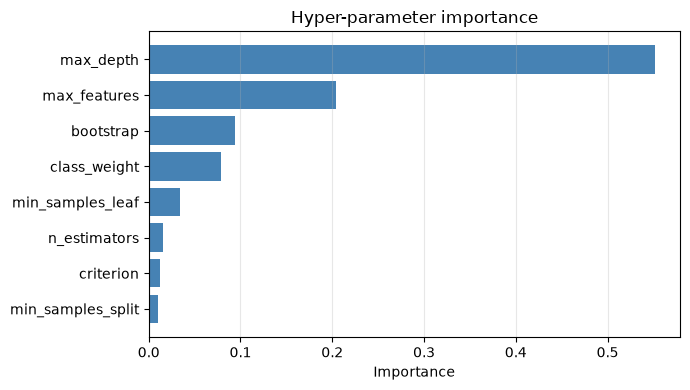

In [19]:
if len(completed) >= 10:
    evaluator = optuna.importance.MeanDecreaseImpurityImportanceEvaluator()

    importance = optuna.importance.get_param_importances(
        study,
        evaluator=evaluator
    )

    importance_series = (
        pd.Series(importance, name="importance")
        .sort_values()
    )

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.barh(
        importance_series.index,
        importance_series.values,
        color="steelblue"
    )
    ax.set_xlabel("Importance")
    ax.set_title("Hyper-parameter importance")
    ax.grid(alpha=0.3, axis="x")
    plt.tight_layout()
    plt.show()
else:
    print(
        f"Only {len(completed)} completed trials; "
        "skipping importance estimate."
    )

## 8. Threshold selection on out-of-fold probabilities

`predict_proba` returns a probability; turning it into a decision needs a cut.
The default 0.5 is arbitrary and usually wrong on imbalanced data.

For a forest the probability is the fraction of trees voting for churn, which
makes the default cut even less principled: it means "more than half the trees
agree", which has no particular business meaning.

The cut is chosen on **out-of-fold** predictions from `cross_val_predict`: every
probability comes from a forest that did not see that row. Tuning it on the test
set would be a second, subtler form of leakage.

In [13]:
cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

oof_proba = cross_val_predict(
    build_model(best_params),
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
)[:, 1]

thresholds = np.arange(0.05, 0.95, 0.01)
oof_f1 = [f1_score(y_train, (oof_proba >= t).astype(int)) for t in thresholds]

best_threshold = float(thresholds[int(np.argmax(oof_f1))])
print(f"Best threshold: {best_threshold:.2f}  (OOF F1 = {max(oof_f1):.4f})")
print(f"F1 at the default 0.50: {f1_score(y_train, (oof_proba >= 0.5).astype(int)):.4f}")

Best threshold: 0.31  (OOF F1 = 0.6400)
F1 at the default 0.50: 0.5627


## 9. How sensitive is F1 to the threshold?

A flat curve around the optimum means the choice is robust; a sharp peak means the
model is fragile and the threshold would need recalibrating in production.

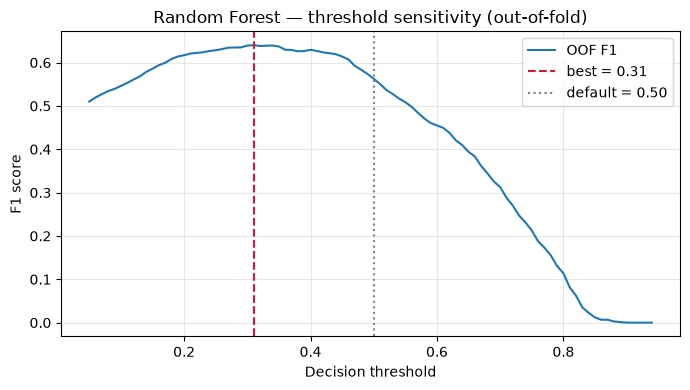

In [14]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(thresholds, oof_f1, label="OOF F1")
ax.axvline(best_threshold, color="crimson", linestyle="--", label=f"best = {best_threshold:.2f}")
ax.axvline(0.5, color="grey", linestyle=":", label="default = 0.50")
ax.set_xlabel("Decision threshold")
ax.set_ylabel("F1 score")
ax.set_title("Random Forest — threshold sensitivity (out-of-fold)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Final training

Hyper-parameters and threshold are now fixed, both chosen using training data
only. The forest is refitted on the **entire** training set: the folds existed to
estimate quality, and holding data back from the final fit would only waste it.

In [15]:
final_model = build_model(best_params)
final_model.fit(X_train, y_train)

depths = [estimator.get_depth() for estimator in final_model.estimators_]
leaves = [estimator.get_n_leaves() for estimator in final_model.estimators_]

print(f"Fitted on {X_train.shape[0]} rows")
print(f"Trees: {len(final_model.estimators_)}")
print(f"Mean depth: {np.mean(depths):.1f}  Mean leaves: {np.mean(leaves):.0f}")

Fitted on 5625 rows
Trees: 250
Mean depth: 8.0  Mean leaves: 117


## 11. Evaluation on the test set

The test set is touched exactly once, here.

Metrics are ordered from most to least informative for this problem.
`average_precision` and `roc_auc` judge the ranking and are threshold-free;
`f1`, `recall` and `precision` judge the decisions at the chosen cut.
**`accuracy` is last on purpose** — a model predicting "no churn" for everyone
scores ~73% here.

In [16]:
test_proba = final_model.predict_proba(X_test)[:, 1]
test_preds = (test_proba >= best_threshold).astype(int)

metrics = {
    "average_precision": average_precision_score(y_test, test_proba),
    "roc_auc": roc_auc_score(y_test, test_proba),
    "f1": f1_score(y_test, test_preds),
    "recall": recall_score(y_test, test_preds),
    "precision": precision_score(y_test, test_preds),
    "balanced_accuracy": balanced_accuracy_score(y_test, test_preds),
    "accuracy": accuracy_score(y_test, test_preds),
}

print(f"Threshold used: {best_threshold:.2f}\n")
pd.Series(metrics, name="random_forest").to_frame().round(4)

Threshold used: 0.31



,random_forest
average_precision,0.6369
roc_auc,0.8346
f1,0.6187
recall,0.7701
precision,0.5171
balanced_accuracy,0.7548
accuracy,0.7477


## 12. Confusion matrix

The business reading of the two error types:

- **False negatives** — churners the model missed. Direct lost revenue.
- **False positives** — loyal customers flagged as at-risk. Cost of a wasted
  retention offer.

Which one hurts more depends on the margin per customer versus the cost of the
offer, and that is exactly the trade-off the threshold controls.

In [17]:
tn, fp, fn, tp = confusion_matrix(y_test, test_preds).ravel()

pd.DataFrame(
    [[tn, fp], [fn, tp]],
    index=["actual: stays", "actual: churns"],
    columns=["predicted: stays", "predicted: churns"],
)

,predicted: stays,predicted: churns
actual: stays,764,269
actual: churns,86,288


## 13. Feature importance

The forest reports mean impurity decrease per feature. Useful, but read it with
two caveats:

1. **It is biased towards high-cardinality features.** Continuous columns such as
   `tenure` or `TotalCharges` offer many possible split points, so they
   accumulate importance more easily than a binary flag does.
2. **It is computed on training data**, so a feature the forest used to memorise
   noise still looks important.

`sklearn.inspection.permutation_importance` on the test set avoids both problems
and is the better choice for the report if the runtime is acceptable.

Unlike the logistic coefficients, these values have **no sign**: they say a
feature matters, not in which direction.

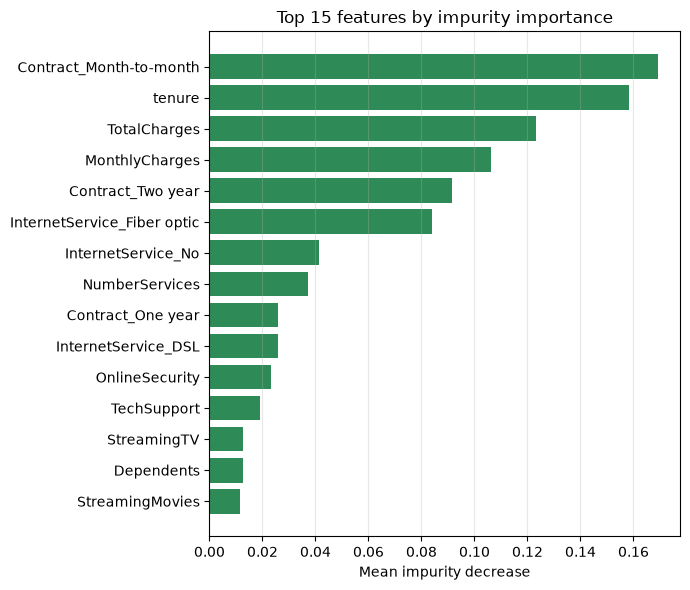

,importance
Contract_Month-to-month,0.1691
tenure,0.1582
TotalCharges,0.1234
MonthlyCharges,0.1061
Contract_Two year,0.0914
InternetService_Fiber optic,0.0838
InternetService_No,0.0412
NumberServices,0.0373
Contract_One year,0.0258
InternetService_DSL,0.0258


In [18]:
importances = (
    pd.Series(final_model.feature_importances_, index=FEATURE_NAMES, name="importance")
    .sort_values(ascending=False)
)

top = importances.head(15)[::-1]

fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(top.index, top.values, color="seagreen")
ax.set_xlabel("Mean impurity decrease")
ax.set_title("Top 15 features by impurity importance")
ax.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

importances.head(10).to_frame().round(4)

## 14. Notes and limitations

**What this notebook establishes.** A tuned bagging ensemble under the same
protocol as the linear baseline, so the difference in `average_precision` is
attributable to the model and not to the evaluation setup.

**Limitations to keep in mind when comparing notebooks.**

- A forest averages hundreds of trees, so the interpretability of a single
  decision tree is gone. Importances say *which* features matter but not *how*,
  and there is no equivalent of a signed coefficient.
- Random forests are known to produce poorly calibrated probabilities — they are
  vote fractions, pushed away from 0 and 1. This is partly why tuning the
  threshold matters more here than for the logistic model. If calibrated
  probabilities are needed, `CalibratedClassifierCV` is the usual fix.
- The threshold is tuned for F1. A different operating point would change the
  decision metrics without changing `average_precision` or `roc_auc`.
- A single train/test split gives a point estimate. Repeating with several seeds
  would put error bars on these numbers.
